# Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Leer dataset

In [2]:
df = pd.read_csv("C:/proyectoANN/student_model_processed.csv")

# Featuring Engineering

In [3]:
df['parent_edu_avg'] = (df['Medu'] + df['Fedu']) / 2
df['alcohol_total'] = df['Dalc'] + df['Walc']

In [4]:
X = df[['G1', 'G2', 'failures', 'studytime', 'absences',
        'parent_edu_avg', 'alcohol_total']]
y = df["risk_level"]

In [5]:
le = LabelEncoder()
y = le.fit_transform(y)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
)


# Escalado

In [7]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Modelo

In [8]:
model = Sequential()
model.add(Dense(units=128, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(units=64, activation="relu"))
model.add(Dropout(0.4))
model.add(Dense(units=32, activation="relu"))
model.add(Dense(units=4, activation='softmax'))

model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
)

# Entrenamiento modelo

In [9]:
early_stop = EarlyStopping(monitor="val_loss", mode="min", patience=10)

model.fit(
        x=X_train,
        y=y_train,
        epochs=55,
        batch_size=64,
        validation_data=(X_test, y_test),
        callbacks=[early_stop]
)

Epoch 1/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4455 - loss: 1.3040 - val_accuracy: 0.4976 - val_loss: 1.2258
Epoch 2/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4994 - loss: 1.1886 - val_accuracy: 0.4976 - val_loss: 1.1447
Epoch 3/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4970 - loss: 1.1387 - val_accuracy: 0.4976 - val_loss: 1.1117
Epoch 4/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4874 - loss: 1.1133 - val_accuracy: 0.4976 - val_loss: 1.0736
Epoch 5/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4946 - loss: 1.0853 - val_accuracy: 0.5024 - val_loss: 1.0389
Epoch 6/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5234 - loss: 1.0475 - val_accuracy: 0.5263 - val_loss: 0.9840
Epoch 7/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5317 - loss: 1.0150 - val_accuracy: 0.5694 - val_loss: 0.9393
Epoch 8/55
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5353 - loss: 0.9778 - val_accuracy: 0.6268 - val_loss

# Resulltados

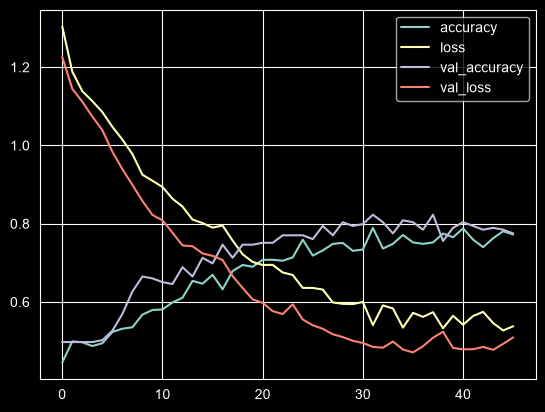

Loss: 0.5094
Accuracy: 0.7751


In [11]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()
plt.show()

results = model.evaluate(X_test, y_test, verbose=0)
print(f"Loss: {results[0]:.4f}")
print(f"Accuracy: {results[1]:.4f}")

In [12]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
              precision    recall  f1-score   support

 Riesgo alto       0.77      0.62      0.69        16
 Riesgo bajo       0.81      0.80      0.81       104
Riesgo medio       0.69      0.37      0.48        30
  Sin riesgo       0.74      0.98      0.85        59

    accuracy                           0.78       209
   macro avg       0.75      0.69      0.71       209
weighted avg       0.77      0.78      0.76       209



In [14]:
predictions = model.predict(X_test)
predictions_lab = np.argmax(predictions, axis=1)

y_prob = model.predict(X_test)
df_test_lab = pd.DataFrame(y_prob, columns=le.classes_).round(4)
df_test_lab['prediccion'] = le.inverse_transform(np.argmax(y_prob, axis=1))
df_test_lab

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Riesgo alto,Riesgo bajo,Riesgo medio,Sin riesgo,prediccion
0,0.0031,0.9310,0.0502,0.0158,Riesgo bajo
1,0.0001,0.6449,0.0017,0.3533,Riesgo bajo
2,0.0029,0.9139,0.0378,0.0454,Riesgo bajo
3,0.0029,0.9286,0.0438,0.0248,Riesgo bajo
4,0.0006,0.9504,0.0218,0.0272,Riesgo bajo
...,...,...,...,...,...
204,0.0368,0.6944,0.2599,0.0089,Riesgo bajo
205,0.0000,0.0294,0.0000,0.9706,Sin riesgo
206,0.0124,0.8398,0.1280,0.0199,Riesgo bajo
207,0.0574,0.5618,0.3750,0.0058,Riesgo bajo


# Matriz de confusion normalizada y sin normalizar

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Confusion matrix sin normalizar
[[10  2  4  0]
 [ 0 83  1 20]
 [ 3 16 11  0]
 [ 0  1  0 58]]
Normalized confusion matrix
[[0.62 0.12 0.25 0.  ]
 [0.   0.8  0.01 0.19]
 [0.1  0.53 0.37 0.  ]
 [0.   0.02 0.   0.98]]


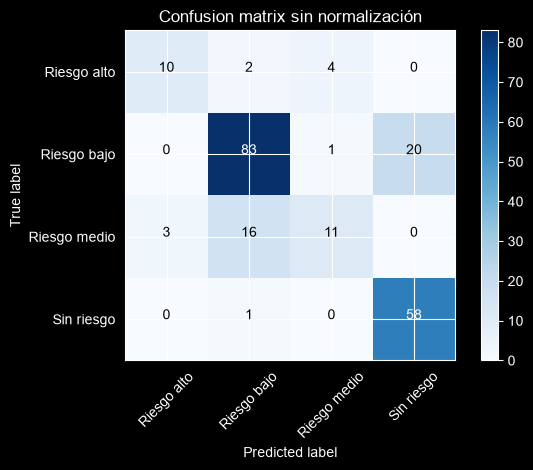

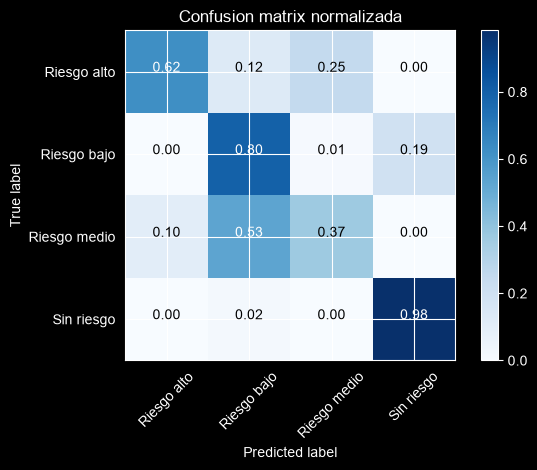

In [15]:
def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Blues):
        if normalize:
                cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
                print("Normalized confusion matrix")
        else:
                print('Confusion matrix sin normalizar')
        print(cm)
        plt.imshow(cm, interpolation='nearest', cmap=cmap)
        plt.title(title)
        plt.colorbar()
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes, rotation=45)
        plt.yticks(tick_marks, classes)
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
                plt.text(j, i, format(cm[i, j], fmt),
                         horizontalalignment="center",
                         color="white" if cm[i, j] > thresh else "black")
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()


clases = le.classes_
y_pred = np.argmax(model.predict(X_test), axis=1)
cnf_matrix = confusion_matrix(y_test, y_pred)
np.set_printoptions(precision=2)

plt.figure()
plot_confusion_matrix(cnf_matrix, classes=clases,
                      title='Confusion matrix sin normalización')
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=clases, normalize=True,
                      title='Confusion matrix normalizada')
plt.show()

# Prediccion con nuevos datos

In [16]:
df_pred = df[['G1', 'G2', 'failures', 'studytime', 'absences',
              'parent_edu_avg', 'alcohol_total']].copy()
X_pred = scaler.transform(df_pred)
y_prob_pred = model.predict(X_pred)
y_pred_clases = le.inverse_transform(np.argmax(y_prob_pred, axis=1))
df_pred['PREDICCIÓN'] = y_pred_clases
df_pred

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,G1,G2,failures,studytime,absences,parent_edu_avg,alcohol_total,PREDICCIÓN
0,5,6,0,2,6,4.0,2,Riesgo alto
1,5,5,0,2,4,1.0,2,Riesgo alto
2,7,8,3,2,10,1.0,5,Riesgo medio
3,15,14,0,3,2,3.0,2,Sin riesgo
4,6,10,0,2,4,3.0,3,Riesgo bajo
...,...,...,...,...,...,...,...,...
1039,10,11,1,3,4,2.5,3,Riesgo bajo
1040,15,15,0,2,4,2.0,2,Sin riesgo
1041,11,12,0,2,6,1.0,2,Riesgo bajo
1042,10,10,0,1,6,2.0,7,Riesgo bajo


# Guardar el modelo

In [21]:
model.save('modelo_riesgo_engineering.keras')

with open('scaler_fe.pkl', 'wb') as f:
        pickle.dump(scaler, f)

with open('label_encoder_fe.pkl', 'wb') as f:
        pickle.dump(le, f)